# MW/M31 Halo Major Merger Remnant Structure


## Topic: Density Profile of the Merged Dark Matter Remnant

```
Maritza Torres
ASTR 400B
Research Assignment 3
```

Main area of focus is analyzing the structure of the Dark Matter remnant after the two galaxies - Milky Way (MW) and Andromeda (M31) merge together.

**Questions:** 
1. What is the density profile of the combined MW + M31 halo? 
2. How does this compare to the original profile of each galaxy halo? 
3. How does this compare to a Hernquist profile or other dark matter profile (e.g. NFW, Isothermal Sphere)?

I will need to compute the density profile of the merged MW/M31 dark matter halos before and after merging using N-body simulations which will model the interaction between the two galaxies. Giving me an overall representation of the mass distribution at different time steps. 

**Primary Objective for this Assignment:**
  Set up and plot a Hernquist Profile for the merged Dark Matter halo at snapshot 455 (~6.5 GYR) to understand the density distribution of the modeled remnant structure.

* Make the Hernquist profile analytically
* Plot the profile to the simulation data for the merged halo
* Use the plot in my final research paper
* Compare it to the other density profiles - combined MW/M31 halo and original profile of each galaxy halo

To begin: Import Python packages

In [1]:
import numpy as np # numpy provides powerful multi-dimensional arrays to hold and manipulate data
import matplotlib.pyplot as plt # matplotlib provides powerful functions for plotting figures
import matplotlib 
import astropy.units as u # astropy provides unit system and constants for astronomical calculations
import astropy.constants as const
from IPython.display import Latex # import Latex module so we can display the results with symbols
%matplotlib inline

Read and upload the snapshots pertaining to after the merge ~6.5 GYR. Snapshot 455

In [3]:
def Read(filename):
    """ This function will be used to read the files infomation line by line so its easier to use in future projects
        Inputs: filename - the name of the file so it can be open and read for the Read function to be used
        Outputs: time, number ,data 
    """
    file = open(filename,'r') # this will open and read the file 
    
    line1 = file.readline() # read the first line 
    label,value = line1.split() # will split each label and value
    time = float(value)*u.Myr # converting units for time
    line2 = file.readline() # read the second line 
    label,value = line2.split() # again just splitting the labels and values
    number = float(value) # the number will be a float from what we calculated from the value function
# close file 
    file.close()
#separates the data types and skips the first 3 lines
    data = np.genfromtxt(filename,dtype=None,names=True,skip_header=3)
    return time, number, data # this will just return the time number and data when it the reader asks to use this function in projects 

In [8]:
time, number,data = Read('MW_455.txt') # the milky way
time2, number2, data2 = Read('M31_455.txt') # andromeda

Get all the Dark Matter particles only (type 1) from each galaxy:

In [19]:
particle = 1 # particle type is 1 for halos/dark matter
i1 = np.where(data['type'] == particle) # #create an array to store indexes of particles of desired Ptype
i2 = np.where(data2['type'] == particle) 

Get the properties for Dark Matter only: 
                  **Mass, Position , Velocity**

In [20]:
# The properties for MW
# postion
x = data['x'][i1]
y = data['y'][i1]
z = data['z'][i1]
# velocity
vx = data['vx'][i1]
vy = data['vy'][i1]
vz = data['vz'][i1]
# mass
m = data['m'][i1]
# the properties for M31
# postion
x2 = data2['x'][i2]
y2 = data2['y'][i2]
z2 = data2['z'][i2]
# velocity
vx2 = data2['vx'][i2]
vy2 = data2['vy'][i2]
vz2 = data2['vz'][i2]
# mass
m2 = data2['m'][i2]

Use concatenation of arrays to combine the MW/M31 Dark Matter properties together:

In [23]:
# number of particles in Dark Matter type
N = len(x) 
N2 = len(x2)
# initialize the data for MW 
MWP = np.zeros((N,3))
MWV = np.zeros((N,3))
MWM = np.zeros(N)
# for loop to get the arrays 
for q in range (N):
    MWP[q] = [x[q],y[q],z[q]]
    MWV[q] = [vx[q],vy[q],vz[q]]
    MWM[q] = m[q]
# M31 
M31P = np.zeros((N2,3))
M31V = np.zeros((N2,3))
M31M = np.zeros(N2)
# for loop to get the array for M31
for q in range (N2):
    MWP[q] = [x2[q],y2[q],z2[q]]
    MWV[q] = [vx2[q],vy2[q],vz2[q]]
    MWM[q] = m2[q]
# now we can plug everything together to get the merged halos
mergedpos = np.concatenate((MWP,M31P), axis=0)
mergedvel = np.concatenate((MWV,M31V), axis=0)
mergedmass = np.concatenate((MWM,M31M), axis=0)

**Now** compute the COM (Center of Mass) for the merged Dark halo distribution using Homework 4. In order to shift the positions to ensure its centered correctly.

We can do this by getting the radial distances of all particles:
```
r=sqrt(x-xcom)^2+(y-ycom)^2+(z-zcom)^2
```

In [ ]:
#code

Compute the bin particles using radial distances:

In [35]:
#code
# use np.histogram() to calculate the particles 

In [ ]:
Lets make a Hernquist function so its easier to plot:

Hernquist Profile:

$\rho(r) =  \frac{M_{halo}}{2\pi} \frac{a}{r(r+a)^3} \qquad  $ 

In [27]:
def Hernquist(r, Mhalo, a):
    """ This function will compute the density for radii within, using the theoretical profile.  
        Inputs: r: `(kpc) this is the distance from the center  
        a: (kpc) the radius length  of the mass density's movement
        Mhalo: (solar mass) the total mass of the halo 
        Returns: HernDens:  the density distribution 
    """ 
    x = ((Mhalo*u.Msun) /(2*np.pi)) # first part of the equation and make conversions
    y = ((a*u.kpc) / ((r*u.kpc)*(r*u.kpc + a*u.kpc )**3)) # the second part of the equation
    Mhalo = x*y # we now multiple both equations 
    return Mhalo  # this is the hernquist density profile in solar mass units

Plot the Hernquist profile:

In [29]:
# using assumptions to make the plot
Mhalo = np.sum(mergedmass) # the total mass
a = 35 # scale radius
r = np.logspace(np.log10(1),np.log10(300),100) # testing radius scales for profile

Hernquist_Profile = Hernquist(r, Mhalo, a)

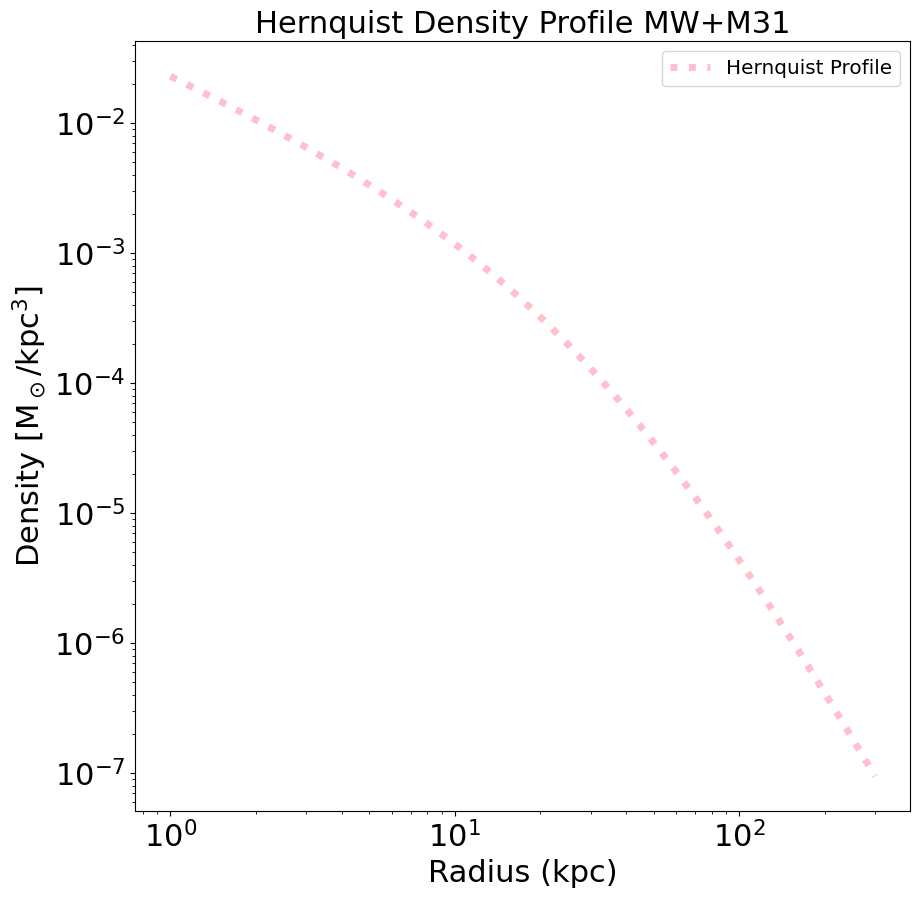

In [34]:
# code for the plot 
fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
ax = plt.subplot(111) 
# Plot the  best fit hernquist profile
ax.loglog(r, Hernquist_Profile, color='pink', linewidth=5,linestyle='dotted', label='Hernquist Profile')
# Add labels
plt.xlabel("Radius (kpc)", fontsize=22)
plt.ylabel("Density [M$_\\odot$/kpc$^3$]", fontsize=22)
plt.title("Hernquist Density Profile MW+M31",fontsize=22)
#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
# add a legend  
legend = ax.legend(loc='upper right',fontsize='x-large')

plt.show() # show the plot

**Overall**, there are still various key components I will need to compute in order to fully answer all the research questions. But this serves as a solid starting point that helps reveal how Dark Matter behaves during major galactic mergers. The Hernquist profile aids in understanding how the structure of a Dark Matter halo evolves throughout the merger. 
* compute the radial distances and bins
* compute center of mass and shift the particle position using the center of mass
* Compute the original MW/M31 Dark Matter density profiles- snapshot '000', comparison between the pre and post merger density distribution
* Overlay the two comparsion into one plot
* Potentially compute the virial properties - R200(radius 200x the critical density) and Rvir(360x critical density), size of the halo compared to the standard models
